# Data Mining and Machine Learning  
## Assignment 2: Clustering using K-Medoids with Jaccard Distance  

---

### Submitted by  
**Deepta Basak (MDS202517)**  
**Arushi Marwaha (MDS202512)**  

---

## Introduction

In this assignment, we perform clustering on text datasets represented using the Bag-of-Words model.  
Each document is treated as a collection of words, and we aim to group similar documents together.

We use:
- **Jaccard distance** as a similarity measure between documents  
- **K-Medoids clustering** instead of K-Means  
- **Elbow method** to determine the optimal number of clusters  

The datasets used are:
- KOS blog entries  
- NIPS papers  
- Enron emails  

## Import Libraries

In [43]:
import numpy as np
import pandas as pd
import gzip
import random
import time
from tqdm import tqdm
import matplotlib.pyplot as plt

#random.seed(42)
#np.random.seed(42)

print("Libraries imported")

Libraries imported


## Methodology

The clustering process follows these steps:

1. **Data Loading**
   - Read compressed dataset files
   - Extract document-word relationships

2. **Set Representation**
   - Convert Bag-of-Words to Set-of-Words
   - Ignore word frequencies

3. **Similarity Measure**
   - Use Jaccard Distance:
     $$
     d(A, B) = 1 - \frac{|A \cap B|}{|A \cup B|}
     $$

4. **Clustering Algorithm**
   - Use K-Medoids (medoids are actual data points)
   - Suitable for non-Euclidean distance

5. **Evaluation**
   - Compute clustering cost
   - Use elbow method to select optimal K

### Loading the Dataset

This function reads the compressed dataset file and extracts:
- Number of documents (D)
- Vocabulary size (W)
- Non-zero entries (NNZ)

It then loads the data into a structured DataFrame.

In [ ]:
def load_docword(filepath):
    print("Loading:", filepath)
    
    # Read header values: number of documents, vocabulary size, and non-zero entries
    with gzip.open(filepath, 'rt') as f:
        D = int(f.readline().strip())
        W = int(f.readline().strip())
        NNZ = int(f.readline().strip())

    print("Documents:", D, "Vocabulary:", W, "NNZ:", NNZ)

    # Load the sparse data into a DataFrame
    df = pd.read_csv(
        filepath,
        sep=' ',
        skiprows=3,
        names=['doc_id', 'word_id', 'count'],
        compression='gzip'
    )

    print("Data loaded")
    print(df.head())
    
    # These stats assume doc_sets has already been created outside this function
    print("Sampled dataset stats:")
    print("Documents:", len(doc_sets))
    print("Average document length:", np.mean([len(v) for v in doc_sets.values()]))

    return D, W, NNZ, df

### Building Document Sets

We convert each document into a set of unique word IDs.

This transforms:
- Bag-of-Words into Set-of-Words

This is required for computing Jaccard similarity.

In [ ]:
def build_doc_sets(df):
    print("Building document sets...")
    
    # Map each document ID to a set of its word IDs
    doc_sets = {}

    # Iterate over rows efficiently
    for row in tqdm(df.itertuples(), total=len(df)):
        doc_id = row.doc_id
        word_id = row.word_id

        # Initialize set for a new document
        if doc_id not in doc_sets:
            doc_sets[doc_id] = set()

        # Add the word to the document's set
        doc_sets[doc_id].add(word_id)

    print("Total documents:", len(doc_sets))
    
    return doc_sets

### Jaccard Distance

We measure similarity between two documents using:

- Intersection - common words  
- Union - total unique words  

This is suitable for sparse text data.

In [ ]:
def jaccard_distance(a, b):
    # Compute size of intersection and union
    intersection = len(a & b)
    union = len(a | b)
    
    # Handle edge case when both sets are empty
    if union == 0:
        return 0

    # Jaccard distance = 1 - similarity
    return 1 - (intersection / union)

## Why K-Medoids Instead of K-Means?

K-Means relies on computing the mean of data points, which is not defined for set-based representations.

Since our data consists of sets and we use Jaccard distance:
- Mean is not meaningful
- Distance is non-Euclidean

Therefore, we use **K-Medoids**, where:
- Cluster centers are actual documents
- Works with arbitrary distance measures

### K-Medoids Clustering

This algorithm:
- Initializes random medoids
- Assigns each document to nearest medoid
- Updates medoids based on cluster structure

Optimizations:
- Sampling within clusters for faster computation
- Early stopping when medoids stabilize

In [ ]:
def k_medoids(doc_sets, k, max_iter=10):
    # Get all document IDs
    doc_ids = list(doc_sets.keys())
    
    # Randomly initialize k medoids
    medoids = random.sample(doc_ids, k)

    print("Starting K =", k)

    prev_medoids = medoids.copy()
    
    for it in range(max_iter):
        print("Iteration", it+1)

        # Initialize empty clusters for each medoid
        clusters = {m: [] for m in medoids}

        # Assign each document to the nearest medoid
        for d in doc_ids:
            distances = [jaccard_distance(doc_sets[d], doc_sets[m]) for m in medoids]
            closest = medoids[np.argmin(distances)]
            clusters[closest].append(d)

        print("Cluster sizes:", [len(v) for v in clusters.values()])

        new_medoids = []
        
        # Update medoids for each cluster
        for m in medoids:
            cluster_docs = clusters[m]
            
            # Handle empty cluster by reinitializing medoid
            if len(cluster_docs) == 0:
                new_medoids.append(random.choice(doc_ids))
                continue

            # Sample subset to reduce computation cost
            sample_size = min(50, len(cluster_docs))
            sample = random.sample(cluster_docs, sample_size)

            # Choose new medoid minimizing total distance to sample
            best = min(
                cluster_docs,
                key=lambda x: sum(
                    jaccard_distance(doc_sets[x], doc_sets[y]) for y in sample
                )
            )

            new_medoids.append(best)

        # Check convergence (no change in medoids)
        if set(new_medoids) == set(prev_medoids):
            print("Converged early at iteration", it+1)
            break

        medoids = new_medoids

    print("Final cluster sizes:", [len(v) for v in clusters.values()])

    return medoids, clusters

### Clustering Cost

We compute the average distance of documents from their assigned medoid.

Lower cost indicates better clustering.

In [ ]:
def compute_cost(clusters, doc_sets):
    # Total distance and number of assignments
    total = 0
    count = 0

    # Iterate over each cluster and its medoid
    for m, docs in clusters.items():
        for d in docs:
            # Add distance of each document to its medoid
            total += jaccard_distance(doc_sets[d], doc_sets[m])
            count += 1

    # Return average distance (cost)
    return total / count if count else 0

### Multiple Runs for Stability

K-Medoids depends on initialization.

To ensure robustness:
- Run algorithm multiple times
- Select clustering with lowest cost

In [ ]:
def run_multiple(doc_sets, k, runs=3):
    # Track best clustering result across runs
    best_cost = float('inf')
    best_clusters = None

    for i in range(runs):
        print("Run", i+1)
        
        # Run k-medoids and compute clustering cost
        medoids, clusters = k_medoids(doc_sets, k)
        cost = compute_cost(clusters, doc_sets)
        print("Cost:", cost)

        # Update best result if current cost is lower
        if cost < best_cost:
            best_cost = cost
            best_clusters = clusters

    return best_clusters, best_cost

## KOS Dataset Results

We run clustering on the KOS dataset.
A subset of documents is sampled for computational efficiency.


Running KOS Dataset
Loading: ./data/docword.kos.txt.gz
Documents: 3430 Vocabulary: 6906 NNZ: 353160
Data loaded
   doc_id  word_id  count
0       1       61      2
1       1       76      1
2       1       89      1
3       1      211      1
4       1      296      1
Sampled dataset stats:
Documents: 4000
Average document length: 96.26725
Building document sets...


100%|██████████| 353160/353160 [00:00<00:00, 2044042.55it/s]


Total documents: 3430
Using 2000 documents

----------------------------
Running K = 2
Run 1
Starting K = 2
Iteration 1
Cluster sizes: [1624, 376]
Iteration 2
Cluster sizes: [706, 1294]
Iteration 3
Cluster sizes: [624, 1376]
Iteration 4
Cluster sizes: [559, 1441]
Iteration 5
Cluster sizes: [614, 1386]
Iteration 6
Cluster sizes: [584, 1416]
Iteration 7
Cluster sizes: [597, 1403]
Iteration 8
Cluster sizes: [657, 1343]
Iteration 9
Cluster sizes: [580, 1420]
Iteration 10
Cluster sizes: [577, 1423]
Final cluster sizes: [577, 1423]
Cost: 0.9170293309445784
Run 2
Starting K = 2
Iteration 1
Cluster sizes: [1062, 938]
Iteration 2
Cluster sizes: [1025, 975]
Iteration 3
Cluster sizes: [1320, 680]
Iteration 4
Cluster sizes: [1013, 987]
Iteration 5
Cluster sizes: [1046, 954]
Iteration 6
Cluster sizes: [1311, 689]
Iteration 7
Cluster sizes: [1531, 469]
Iteration 8
Cluster sizes: [1534, 466]
Iteration 9
Cluster sizes: [1324, 676]
Iteration 10
Cluster sizes: [1325, 675]
Final cluster sizes: [1325, 675

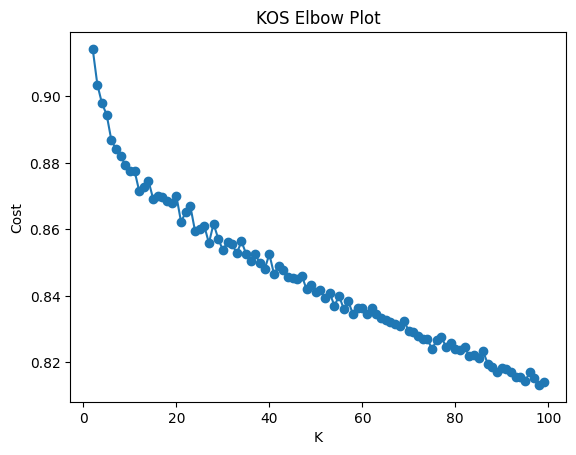

In [ ]:
# KOS dataset experiment

data_path = "./data"

print("\n============================")
print("Running KOS Dataset")
print("============================")

# Load dataset and metadata
D, W, NNZ, df = load_docword(f"{data_path}/docword.kos.txt.gz")

# Build document-wise word sets
doc_sets = build_doc_sets(df)

# Randomly sample a subset of documents for efficiency
sample_size = 2000
sample_keys = random.sample(list(doc_sets.keys()), sample_size)
doc_sets = {k: doc_sets[k] for k in sample_keys}

print("Using", len(doc_sets), "documents")

# Try different values of K
k_values = range(2, 100)
costs_kos = []

for k in k_values:
    print("\n----------------------------")
    print("Running K =", k)

    start = time.time()

    # Run clustering and compute cost
    clusters, cost = run_multiple(doc_sets, k)

    end = time.time()

    print("Final Cost:", cost)
    print("Time taken:", end - start)

    # Store cost for elbow plot
    costs_kos.append(cost)

# Plot cost vs K
plt.plot(list(k_values), costs_kos, marker='o')
plt.xlabel("K")
plt.ylabel("Cost")
plt.title("KOS Elbow Plot")
plt.show()

Observation:
The cost decreases sharply initially and then begins to flatten around K ≈ 12, indicating diminishing returns.

## NIPS Dataset Results

We apply the same clustering procedure to the NIPS dataset.
Due to moderate size, limited sampling is used.


Running NIPS Dataset
Loading: ./data/docword.nips.txt.gz
Documents: 1500 Vocabulary: 12419 NNZ: 746316
Data loaded
   doc_id  word_id  count
0       1        2      1
1       1       39      1
2       1       42      3
3       1       77      1
4       1       95      1
Sampled dataset stats:
Documents: 2000
Average document length: 102.891
Building document sets...


100%|██████████| 746316/746316 [00:00<00:00, 2135093.95it/s]


Total documents: 1500
Using 1200 documents

----------------------------
Running K = 2
Run 1
Starting K = 2
Iteration 1
Cluster sizes: [655, 545]
Iteration 2
Cluster sizes: [924, 276]
Iteration 3
Cluster sizes: [847, 353]
Iteration 4
Cluster sizes: [614, 586]
Iteration 5
Cluster sizes: [407, 793]
Iteration 6
Cluster sizes: [743, 457]
Iteration 7
Cluster sizes: [894, 306]
Iteration 8
Cluster sizes: [629, 571]
Iteration 9
Cluster sizes: [542, 658]
Iteration 10
Cluster sizes: [434, 766]
Final cluster sizes: [434, 766]
Cost: 0.8481086109935554
Run 2
Starting K = 2
Iteration 1
Cluster sizes: [980, 220]
Iteration 2
Cluster sizes: [613, 587]
Iteration 3
Cluster sizes: [573, 627]
Iteration 4
Cluster sizes: [707, 493]
Iteration 5
Cluster sizes: [599, 601]
Iteration 6
Cluster sizes: [646, 554]
Iteration 7
Cluster sizes: [710, 490]
Iteration 8
Cluster sizes: [291, 909]
Iteration 9
Cluster sizes: [303, 897]
Iteration 10
Cluster sizes: [616, 584]
Final cluster sizes: [616, 584]
Cost: 0.846544668266

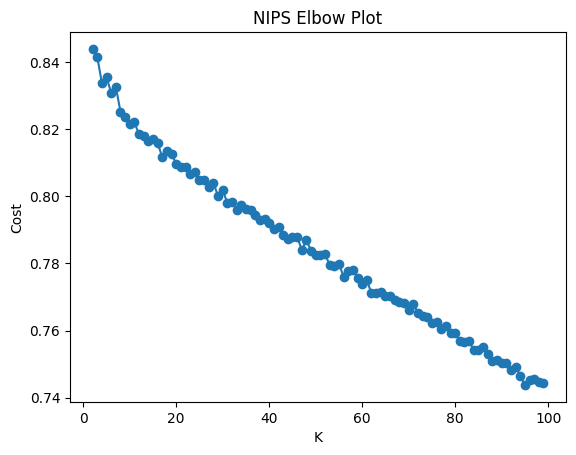

In [ ]:
# NIPS dataset experiment

data_path = "./data"

print("\n============================")
print("Running NIPS Dataset")
print("============================")

# Load dataset and metadata
D, W, NNZ, df = load_docword(f"{data_path}/docword.nips.txt.gz")

# Build document-wise word sets
doc_sets = build_doc_sets(df)

# Randomly sample a subset for efficiency
sample_size = 1200
sample_keys = random.sample(list(doc_sets.keys()), sample_size)
doc_sets = {k: doc_sets[k] for k in sample_keys}

print("Using", len(doc_sets), "documents")

# Try different values of K
k_values = range(2, 100)
costs_nips = []

for k in k_values:
    print("\n----------------------------")
    print("Running K =", k)

    start = time.time()

    # Run clustering and compute cost
    clusters, cost = run_multiple(doc_sets, k)

    end = time.time()

    print("Final Cost:", cost)
    print("Time taken:", end - start)

    # Store cost for elbow plot
    costs_nips.append(cost)

# Plot cost vs K
plt.plot(list(k_values), costs_nips, marker='o')
plt.xlabel("K")
plt.ylabel("Cost")
plt.title("NIPS Elbow Plot")
plt.show()

Observation:
The cost decreases steadily, with faster reduction for smaller K and gradual decline after K ≈ 10.

## Enron Dataset Results

The Enron dataset is significantly larger.
Hence, random sampling is used to make computation feasible.


Running Enron Dataset
Loading: ./data/docword.enron.txt.gz
Documents: 39861 Vocabulary: 28102 NNZ: 3710420
Data loaded
   doc_id  word_id  count
0       1      118      1
1       1      285      1
2       1     1229      1
3       1     1688      1
4       1     2068      1
Sampled dataset stats:
Documents: 1200
Average document length: 498.6041666666667
Building document sets...


100%|██████████| 3710420/3710420 [00:01<00:00, 2068039.14it/s]


Total documents: 39861
Using 4000 documents

----------------------------
Running K = 2
Run 1
Starting K = 2
Iteration 1
Cluster sizes: [3268, 732]
Iteration 2
Cluster sizes: [2599, 1401]
Iteration 3
Cluster sizes: [3348, 652]
Iteration 4
Cluster sizes: [3378, 622]
Iteration 5
Cluster sizes: [3326, 674]
Iteration 6
Cluster sizes: [3272, 728]
Iteration 7
Cluster sizes: [3461, 539]
Iteration 8
Cluster sizes: [3252, 748]
Iteration 9
Cluster sizes: [3018, 982]
Iteration 10
Cluster sizes: [3360, 640]
Final cluster sizes: [3360, 640]
Cost: 0.9630404240021758
Run 2
Starting K = 2
Iteration 1
Cluster sizes: [2897, 1103]
Iteration 2
Cluster sizes: [3336, 664]
Iteration 3
Cluster sizes: [2343, 1657]
Iteration 4
Cluster sizes: [1373, 2627]
Iteration 5
Cluster sizes: [1694, 2306]
Iteration 6
Cluster sizes: [1001, 2999]
Iteration 7
Cluster sizes: [1207, 2793]
Iteration 8
Cluster sizes: [1804, 2196]
Iteration 9
Cluster sizes: [3261, 739]
Iteration 10
Cluster sizes: [3282, 718]
Final cluster sizes: [

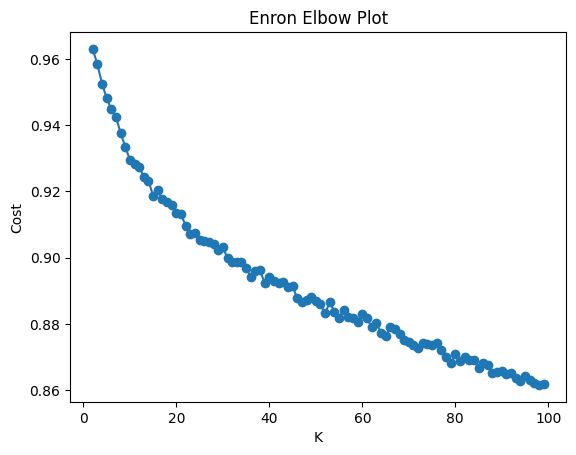

In [ ]:
# Enron dataset experiment

data_path = "./data"

print("\n============================")
print("Running Enron Dataset")
print("============================")

# Load dataset and metadata
D, W, NNZ, df = load_docword(f"{data_path}/docword.enron.txt.gz")

# Build document-wise word sets
doc_sets = build_doc_sets(df)

# Strong sampling due to large dataset size
sample_size = 4000
sample_keys = random.sample(list(doc_sets.keys()), sample_size)
doc_sets = {k: doc_sets[k] for k in sample_keys}

print("Using", len(doc_sets), "documents")

# Try different values of K
k_values = range(2, 100)
costs_enron = []

for k in k_values:
    print("\n----------------------------")
    print("Running K =", k)

    start = time.time()

    # Run clustering and compute cost
    clusters, cost = run_multiple(doc_sets, k)

    end = time.time()

    print("Final Cost:", cost)
    print("Time taken:", end - start)

    # Store cost for elbow plot
    costs_enron.append(cost)

# Plot cost vs K
plt.plot(list(k_values), costs_enron, marker='o')
plt.xlabel("K")
plt.ylabel("Cost")
plt.title("Enron Elbow Plot")
plt.show()

Observation:
The cost decreases smoothly with no sharp elbow, but the rate of decrease slows down after K ≈ 12.

## Challenges and Optimizations

- Large dataset sizes (especially Enron)
- High computational cost of Jaccard distance

Optimizations used:
- Random sampling of documents
- Sampling within clusters during medoid update
- Multiple runs for stable results

## Final Observations and Conclusion

### KOS Dataset
From the elbow plot, the cost decreases sharply till K = 10–12 and then starts to flatten with a much slower rate of decrease.
Hence, the optimal number of clusters is approximately K = 12.

### NIPS Dataset
From the elbow plot, the cost decreases significantly till K = 8–10.
After that, the improvement becomes more gradual and nearly linear.
Hence, optimal K ≈ 10.

### Enron Dataset
Due to the large size, sampling was used.
The elbow plot shows a noticeable reduction in the rate of decrease after K = 10–12.
Hence, the optimal number of clusters is around K ≈ 12.

## Computational Complexity

- Assignment step: O(NK)
- Medoid update: O(N²) within clusters
- Optimizations reduce practical runtime

This was necessary due to large-scale datasets.

### Overall Conclusion
- Increasing K reduces clustering cost.
- However, beyond a certain point, the improvement becomes negligible.
- This point is chosen as the optimal number of clusters.
- For all three datasets, moderate values of K (around 10–12) provide a good balance between clustering quality and complexity.